# Analisis Komparatif Strategi Seleksi Klien pada Federated Learning
**Dataset**: MNIST & CIFAR-10 | **Alpha**: 0.1, 0.5, 1.0 | **Seeds**: 42, 123, 456

> Notebook ini bisa dijalankan sebagian (hanya eksperimen yang sudah selesai) maupun penuh (54 eksperimen). Cell yang butuh CIFAR-10 atau alpha tertentu akan skip otomatis jika data belum ada.

In [79]:
# ── Helper: save figure ──────────────────────────────────────────────
def savefig(name, dpi=150):
    path = FIG_DIR / f'{name}.png'
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f'  ✓ Saved: {path.name}')
    plt.show()

## 0. Setup & Load Data

In [80]:
import json
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from itertools import product

warnings.filterwarnings('ignore')

# ── Path setup ──────────────────────────────────────────────────────────
# Auto-detect ROOT: cari folder yang punya subfolder 'results' dan 'src'
_cwd = Path('.').resolve()
ROOT = _cwd
for candidate in [_cwd, _cwd.parent, _cwd.parent.parent]:
    if (candidate / 'results').exists() and (candidate / 'src').exists():
        ROOT = candidate
        break

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'ROOT    : {ROOT}')
print(f'results : {ROOT / "results"}')
print(f'exists  : {(ROOT / "results").exists()}')

# Debug: lihat isi folder results
RESULTS_DIR = ROOT / 'results'
if RESULTS_DIR.exists():
    all_exp_dirs = [d.name for d in RESULTS_DIR.iterdir() if d.is_dir()]
    print(f'\nFolder di results/ ({len(all_exp_dirs)} total):')
    for d in sorted(all_exp_dirs)[:]:
        print(f'  {d}')
    # if len(all_exp_dirs) > 10:
    #     print(f'  ... dan {len(all_exp_dirs)-10} lainnya')
else:
    print('\nWARNING: folder results/ tidak ditemukan!')

ROOT    : /home/fayzul/codebase/fl_experiment/fl_experiment
results : /home/fayzul/codebase/fl_experiment/fl_experiment/results
exists  : True

Folder di results/ (54 total):
  fairness_cifar10_a0.1_s123
  fairness_cifar10_a0.1_s42
  fairness_cifar10_a0.1_s456
  fairness_cifar10_a0.5_s123
  fairness_cifar10_a0.5_s42
  fairness_cifar10_a0.5_s456
  fairness_cifar10_a1.0_s123
  fairness_cifar10_a1.0_s42
  fairness_cifar10_a1.0_s456
  fairness_mnist_a0.1_s123
  fairness_mnist_a0.1_s42
  fairness_mnist_a0.1_s456
  fairness_mnist_a0.5_s123
  fairness_mnist_a0.5_s42
  fairness_mnist_a0.5_s456
  fairness_mnist_a1.0_s123
  fairness_mnist_a1.0_s42
  fairness_mnist_a1.0_s456
  performance_cifar10_a0.1_s123
  performance_cifar10_a0.1_s42
  performance_cifar10_a0.1_s456
  performance_cifar10_a0.5_s123
  performance_cifar10_a0.5_s42
  performance_cifar10_a0.5_s456
  performance_cifar10_a1.0_s123
  performance_cifar10_a1.0_s42
  performance_cifar10_a1.0_s456
  performance_mnist_a0.1_s123
  performanc

In [81]:
# ── Style konsisten ─────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
STRATEGY_COLORS = {
    'random':      '#1f77b4',   # biru
    'performance': '#ff7f0e',   # oranye
    'fairness':    '#2ca02c',   # hijau
}
STRATEGY_LABELS = {
    'random':      'Random (FedAvg)',
    'performance': 'Performance-Based',
    'fairness':    'Fairness-Aware',
}
ALPHA_MARKERS = {0.1: 'o', 0.5: 's', 1.0: '^'}
DATASET_LINESTYLE = {'mnist': '-', 'cifar10': '--'}

STRATEGIES = ['random', 'performance', 'fairness']
DATASETS   = ['mnist', 'cifar10']
ALPHAS     = [0.1, 0.5, 1.0]
SEEDS      = [42, 123, 456]

RESULTS_DIR    = ROOT / 'results'
PARTITION_DIR  = ROOT / 'data' / 'partitions'
FIG_DIR        = ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Figures → {FIG_DIR}')

Figures → /home/fayzul/codebase/fl_experiment/fl_experiment/notebooks/figures


In [82]:
# ── Load semua hasil eksperimen ──────────────────────────────────────────
records = []   # satu baris per eksperimen
missing = []


for strategy, dataset, alpha, seed in product(STRATEGIES, DATASETS, ALPHAS, SEEDS):
    exp_id  = f'{strategy}_{dataset}_a{alpha}_s{seed}'
    exp_dir = RESULTS_DIR / exp_id
    fm_path = exp_dir / 'final_metrics.json'
    pr_path = exp_dir / 'metrics_per_round.json'
    pa_path = exp_dir / 'participation_log.json'

    if not fm_path.exists():
        missing.append(exp_id)
        continue

    fm = json.loads(fm_path.read_text())
    pr = json.loads(pr_path.read_text()) if pr_path.exists() else []
    pa = json.loads(pa_path.read_text()) if pa_path.exists() else {}

    records.append({
        # identitas
        'exp_id':   exp_id,
        'strategy': strategy,
        'dataset':  dataset,
        'alpha':    alpha,
        'seed':     seed,
        # metrik A
        'A1': fm.get('A1_global_accuracy', np.nan),
        'A2': fm.get('A2_rounds_to_target', np.nan),
        'target_reached': fm.get('target_reached', False),
        # metrik B
        'B1': fm.get('B1_accuracy_variance', np.nan),
        'B2': fm.get('B2_gini_coefficient', np.nan),
        'B3': fm.get('B3_participation_fairness', np.nan),
        # history
        'acc_history':      fm.get('accuracy_history', []),
        'per_client_final': fm.get('per_client_final', []),
        'per_round':        pr,
        'participation':    pa,
        # waktu
        'time_s': fm.get('total_time_seconds', np.nan),
    })

df = pd.DataFrame(records)

print(f'Loaded  : {len(df)} eksperimen')
print(f'Missing : {len(missing)} eksperimen')
if missing:
    for m in missing[:10]:
        print(f'  - {m}')
    if len(missing) > 10:
        print(f'  ... dan {len(missing)-10} lainnya')

# Subsets yang sering dipakai
df_mnist  = df[df.dataset == 'mnist'].copy()
df_cifar  = df[df.dataset == 'cifar10'].copy()

df.head(3)

Loaded  : 54 eksperimen
Missing : 0 eksperimen


,exp_id,strategy,dataset,alpha,seed,A1,A2,target_reached,B1,B2,B3,acc_history,per_client_final,per_round,participation,time_s
0,random_mnist_a0.1_s42,random,mnist,0.1,42,98.55,4.0,True,0.016473,0.008839,2.280351,"[73.15, 69.84, 76.72, 89.23, 94.1, 96.44, 94.0...","[0.9950988536301711, 0.9989031880666862, 0.976...","[{'round': 0, 'global_accuracy': 6.4, 'per_cli...","{'final_counts': {'1': 13, '3': 8, '4': 8, '7'...",324.77
1,random_mnist_a0.1_s123,random,mnist,0.1,123,98.75,4.0,True,0.008666,0.004812,2.190890,"[62.529999999999994, 72.05, 77.44, 92.96, 95.8...","[0.9858293970547374, 0.9838788470933073, 0.966...","[{'round': 0, 'global_accuracy': 13.1700000000...","{'final_counts': {'1': 11, '5': 6, '6': 9, '8'...",339.76
2,random_mnist_a0.1_s456,random,mnist,0.1,456,97.31,4.0,True,0.019302,0.010755,1.414214,"[56.54, 65.82000000000001, 66.99000000000001, ...","[0.9667579194368401, 0.9983488132094943, 0.986...","[{'round': 0, 'global_accuracy': 18.86, 'per_c...","{'final_counts': {'0': 12, '3': 11, '4': 10, '...",333.54


## 1. Visualisasi Partisi Dirichlet (Data Non-IID)

  ✓ Saved: 01_partition_per_alpha.png


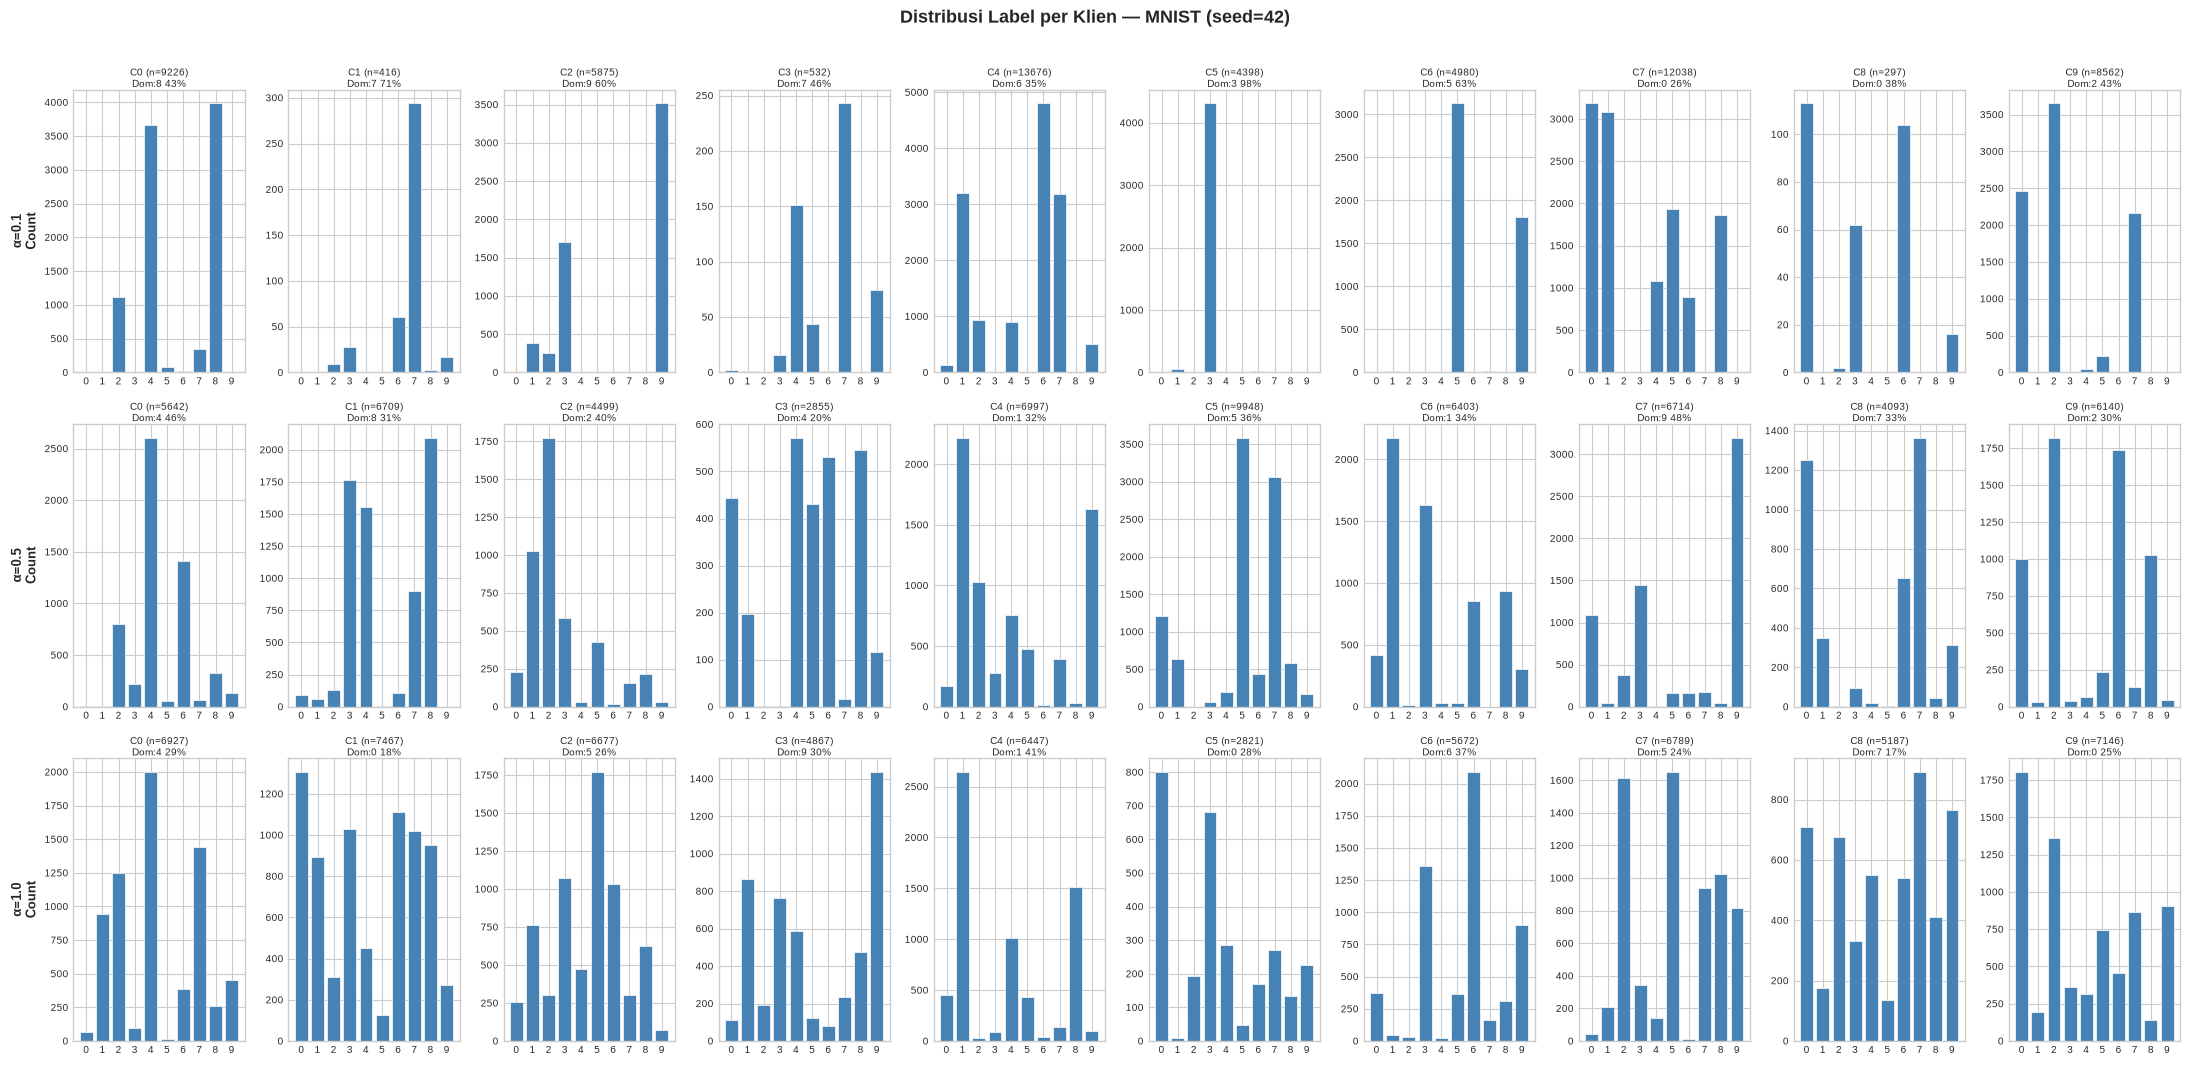

In [83]:
# ── 1A: Distribusi label per klien untuk 3 nilai alpha ──────────────────
# Tunjukkan betapa berbedanya distribusi label ketika alpha berubah

from src.data.partitioner import load_partition_info, check_partition_exists

dataset_viz = 'mnist'
seed_viz    = 42

available_alphas = [a for a in ALPHAS
                    if check_partition_exists(dataset_viz, a, seed_viz)]

if not available_alphas:
    print('Partisi belum ada. Jalankan prepare_data.py dulu.')
else:
    n_alphas = len(available_alphas)
    fig, axes = plt.subplots(n_alphas, 10, figsize=(22, 3.5 * n_alphas))
    if n_alphas == 1:
        axes = [axes]

    for row_idx, alpha in enumerate(available_alphas):
        infos = load_partition_info(dataset_viz, alpha, seed_viz)
        for col_idx, info in enumerate(infos):
            ax = axes[row_idx][col_idx]
            cd = info['class_distribution']
            classes = list(range(10))
            counts  = [cd.get(str(c), 0) for c in classes]

            ax.bar(classes, counts, color='steelblue', edgecolor='white', linewidth=0.5)
            ax.set_xticks(range(10))
            ax.set_xlim(-0.8, 9.8)
            ax.tick_params(labelsize=7)

            dom_pct = info['dominant_class_pct']
            ax.set_title(f"C{info['client_id']} (n={info['total_samples']})\nDom:{info['dominant_class']} {dom_pct:.0f}%",
                         fontsize=7.5, pad=2)

            if col_idx == 0:
                ax.set_ylabel(f'α={alpha}\nCount', fontsize=9, fontweight='bold')

    plt.suptitle(f'Distribusi Label per Klien — {dataset_viz.upper()} (seed={seed_viz})',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    savefig('01_partition_per_alpha')

  ✓ Saved: 02_partition_heatmap.png


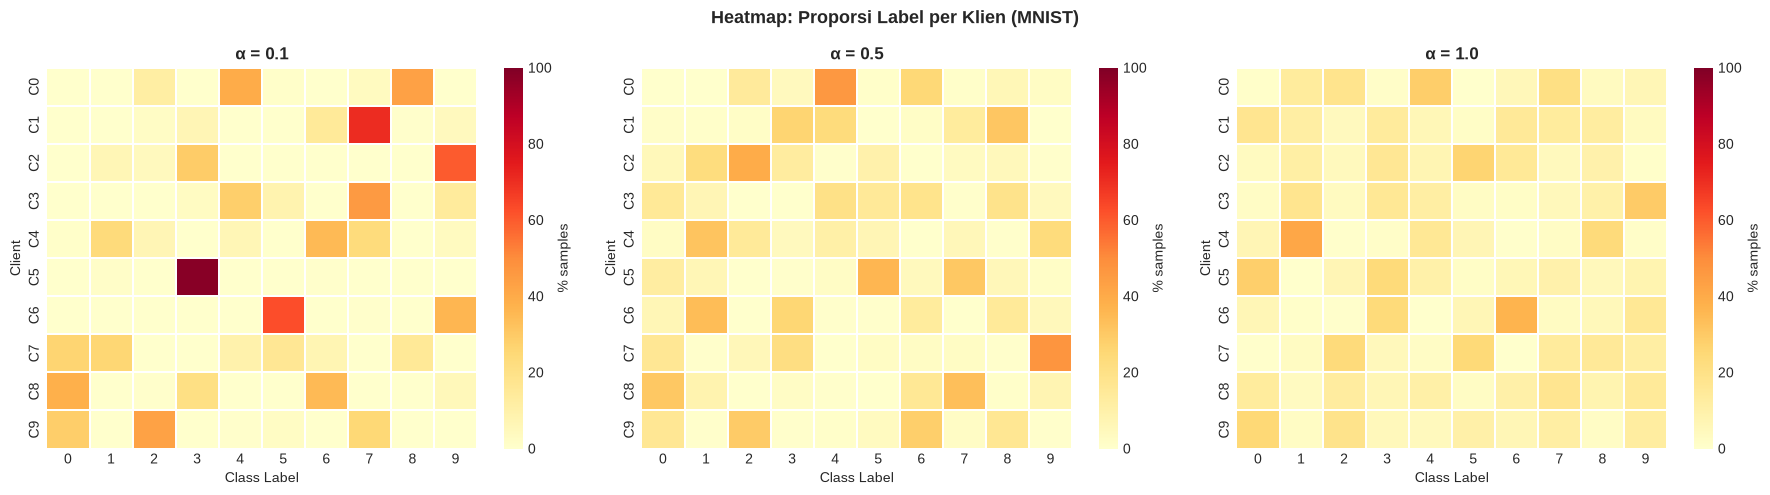

In [84]:
# ── 1B: Heatmap class distribution (ringkas, lebih mudah dibandingkan) ──

available_alphas = [a for a in ALPHAS
                    if check_partition_exists('mnist', a, 42)]

if available_alphas:
    fig, axes = plt.subplots(1, len(available_alphas),
                             figsize=(6 * len(available_alphas), 5))
    if len(available_alphas) == 1:
        axes = [axes]

    for ax, alpha in zip(axes, available_alphas):
        infos = load_partition_info('mnist', alpha, 42)
        matrix = np.zeros((10, 10))   # clients × classes
        for info in infos:
            cd = info['class_distribution']
            total = info['total_samples']
            for c in range(10):
                matrix[info['client_id'], c] = cd.get(str(c), 0) / total * 100

        sns.heatmap(matrix, ax=ax, cmap='YlOrRd', vmin=0, vmax=100,
                    xticklabels=range(10), yticklabels=[f'C{i}' for i in range(10)],
                    linewidths=0.3, cbar_kws={'label': '% samples'})
        ax.set_title(f'α = {alpha}', fontweight='bold', fontsize=12)
        ax.set_xlabel('Class Label')
        ax.set_ylabel('Client')

    plt.suptitle('Heatmap: Proporsi Label per Klien (MNIST)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig('02_partition_heatmap')

In [85]:
# ── 1C: Statistik ringkas partisi ───────────────────────────────────────

part_stats = []
for dataset in DATASETS:
    for alpha in ALPHAS:
        for seed in SEEDS:
            if not check_partition_exists(dataset, alpha, seed):
                continue
            infos = load_partition_info(dataset, alpha, seed)
            dom_pcts = [info['dominant_class_pct'] for info in infos]
            sample_counts = [info['total_samples'] for info in infos]
            missing_cls = [len(info.get('missing_classes', [])) for info in infos]
            part_stats.append({
                'dataset': dataset, 'alpha': alpha, 'seed': seed,
                'mean_dom_pct': np.mean(dom_pcts),
                'std_dom_pct':  np.std(dom_pcts),
                'mean_samples': np.mean(sample_counts),
                'std_samples':  np.std(sample_counts),
                'mean_missing': np.mean(missing_cls),
            })

if part_stats:
    df_part = pd.DataFrame(part_stats)
    summary = df_part.groupby(['dataset','alpha']).agg(
        mean_dom_pct=('mean_dom_pct','mean'),
        std_dom_pct=('std_dom_pct','mean'),
        mean_missing=('mean_missing','mean'),
    ).round(2)
    print('Statistik Partisi (rata-rata across seeds):')
    print(summary.to_string())
    print()
    print('Interpretasi:')
    print('  mean_dom_pct : rata-rata % sampel dari kelas dominan per klien')
    print('  std_dom_pct  : variasi dominant class % antar klien')
    print('  mean_missing : rata-rata kelas yang tidak ada (0 sampel) per klien')
    print('  → Alpha kecil (0.1) = skew lebih ekstrem = mean_dom_pct lebih tinggi')

Statistik Partisi (rata-rata across seeds):
               mean_dom_pct  std_dom_pct  mean_missing
dataset alpha                                         
cifar10 0.1           61.82        21.11          3.63
        0.5           38.53        11.08          0.07
        1.0           27.43         6.02          0.00
mnist   0.1           59.67        19.75          3.13
        0.5           34.91         8.75          0.13
        1.0           27.54         6.24          0.00

Interpretasi:
  mean_dom_pct : rata-rata % sampel dari kelas dominan per klien
  std_dom_pct  : variasi dominant class % antar klien
  mean_missing : rata-rata kelas yang tidak ada (0 sampel) per klien
  → Alpha kecil (0.1) = skew lebih ekstrem = mean_dom_pct lebih tinggi


## 2. Overview Eksperimen (Section 1 Saran)

In [86]:
# ── 2A: Status eksperimen ────────────────────────────────────────────────
total_planned = len(STRATEGIES) * len(DATASETS) * len(ALPHAS) * len(SEEDS)
n_done = len(df)
n_missing = len(missing)

print('='*55)
print(f'  EXPERIMENT STATUS')
print('='*55)
print(f'  Planned  : {total_planned} (3 strategi × 2 dataset × 3 alpha × 3 seed)')
print(f'  Completed: {n_done} ({n_done/total_planned*100:.1f}%)')
print(f'  Missing  : {n_missing}')
print()

if n_done > 0:
    pivot = df.pivot_table(values='A1', index=['dataset','alpha'],
                           columns='strategy', aggfunc='count')
    print('Eksperimen selesai per (dataset, alpha, strategi):')
    print(pivot.fillna(0).astype(int).to_string())
    print('(nilai = jumlah seeds yang selesai, maks 3)')

  EXPERIMENT STATUS
  Planned  : 54 (3 strategi × 2 dataset × 3 alpha × 3 seed)
  Completed: 54 (100.0%)
  Missing  : 0

Eksperimen selesai per (dataset, alpha, strategi):
strategy       fairness  performance  random
dataset alpha                               
cifar10 0.1           3            3       3
        0.5           3            3       3
        1.0           3            3       3
mnist   0.1           3            3       3
        0.5           3            3       3
        1.0           3            3       3
(nilai = jumlah seeds yang selesai, maks 3)


In [87]:
# ── 2B: Tabel hyperparameter konfigurasi ────────────────────────────────
config = {
    'Parameter': ['Num Clients', 'Clients per Round', 'Local Epochs',
                  'Learning Rate', 'Rounds', 'Target Acc (MNIST)',
                  'Target Acc (CIFAR-10)', 'Dirichlet Alpha', 'Seeds'],
    'Value': [10, 5, 3, 0.01, 20, '85%', '70%', '[0.1, 0.5, 1.0]', '[42, 123, 456]'],
    'Keterangan': [
        'Total klien dalam simulasi',
        'Dipilih per communication round',
        'Epoch training lokal tiap klien',
        'SGD learning rate',
        'Jumlah communication rounds',
        'Threshold convergence MNIST',
        'Threshold convergence CIFAR-10',
        'Parameter skew label Non-IID',
        'Untuk reproducibility',
    ]
}
pd.DataFrame(config)

,Parameter,Value,Keterangan
0,Num Clients,10,Total klien dalam simulasi
1,Clients per Round,5,Dipilih per communication round
2,Local Epochs,3,Epoch training lokal tiap klien
3,Learning Rate,0.01,SGD learning rate
4,Rounds,20,Jumlah communication rounds
5,Target Acc (MNIST),85%,Threshold convergence MNIST
6,Target Acc (CIFAR-10),70%,Threshold convergence CIFAR-10
7,Dirichlet Alpha,"[0.1, 0.5, 1.0]",Parameter skew label Non-IID
8,Seeds,"[42, 123, 456]",Untuk reproducibility


## 3. Perbandingan Global Performance (A1 & A2)

  ✓ Saved: 03_heatmap_A1.png


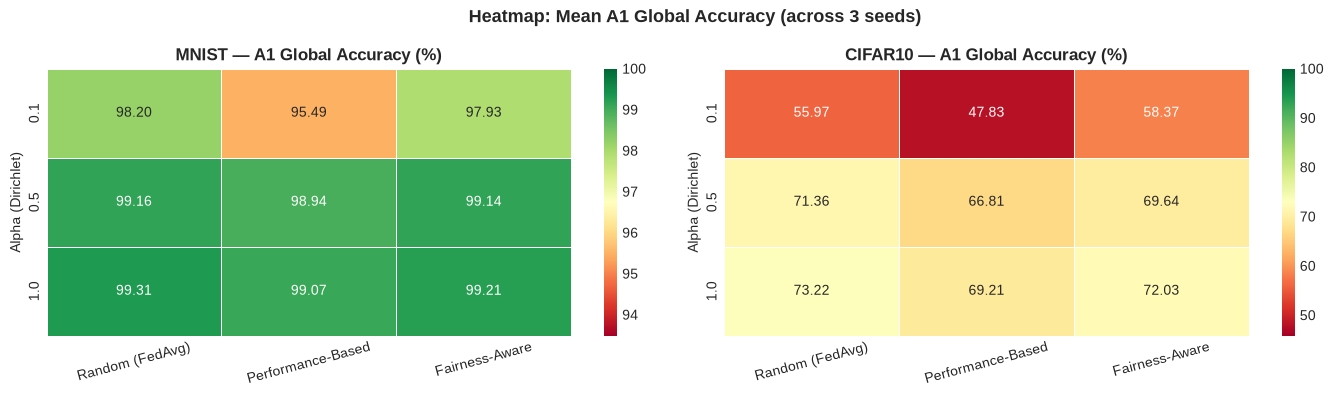

In [88]:
# ── 3A: Heatmap A1 (mean across seeds) ──────────────────────────────────
# Rows=alpha, Cols=strategi, Subplot=dataset

available_datasets = [d for d in DATASETS if d in df.dataset.values]

if not available_datasets:
    print('Belum ada hasil eksperimen.')
else:
    fig, axes = plt.subplots(1, len(available_datasets),
                             figsize=(7 * len(available_datasets), 4))
    if len(available_datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, available_datasets):
        sub = df[df.dataset == dataset]
        pivot = sub.pivot_table(values='A1', index='alpha',
                                columns='strategy', aggfunc='mean')
        pivot = pivot.reindex(columns=STRATEGIES)

        sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
                    vmin=pivot.values[~np.isnan(pivot.values)].min() - 2 if pivot.notna().any().any() else 0,
                    vmax=100, linewidths=0.5,
                    xticklabels=[STRATEGY_LABELS[s] for s in pivot.columns])
        ax.set_title(f'{dataset.upper()} — A1 Global Accuracy (%)', fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Alpha (Dirichlet)')
        ax.tick_params(axis='x', rotation=15)

    plt.suptitle('Heatmap: Mean A1 Global Accuracy (across 3 seeds)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig('03_heatmap_A1')

  ✓ Saved: 04_boxplot_A1.png


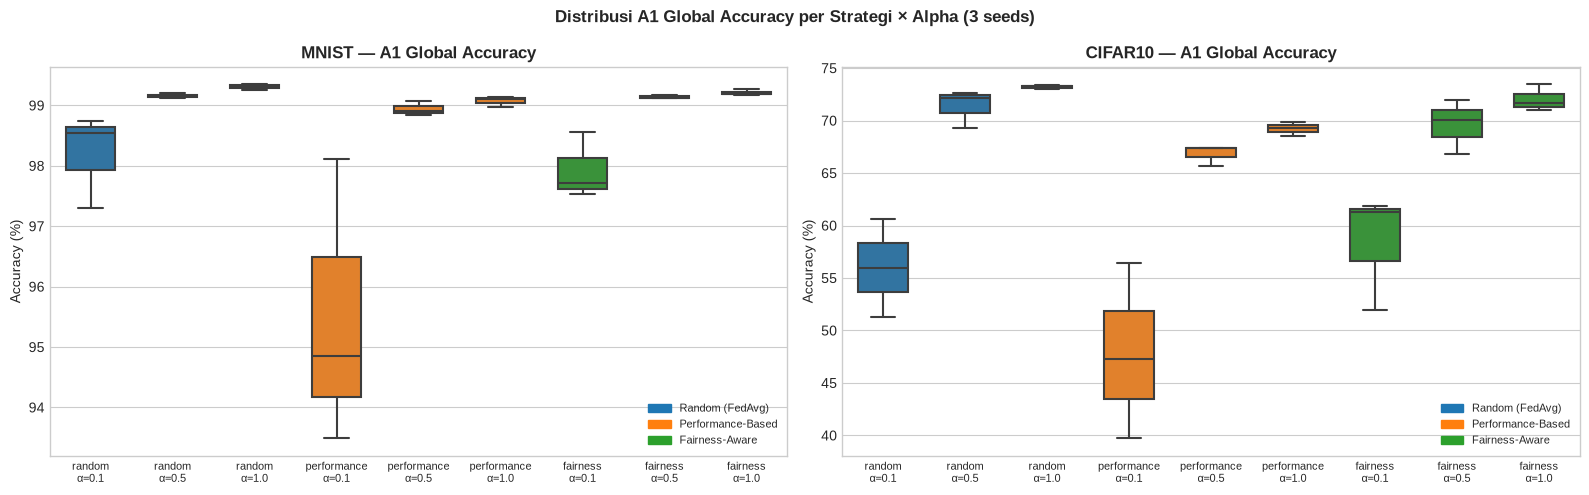

In [89]:
# ── 3B: A1 Boxplot per strategi × alpha (distribusi across seeds) ────────

available_datasets = [d for d in DATASETS if d in df.dataset.values]

if available_datasets:
    fig, axes = plt.subplots(1, len(available_datasets),
                             figsize=(8 * len(available_datasets), 5),
                             sharey=False)
    if len(available_datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, available_datasets):
        sub = df[df.dataset == dataset]
        if sub.empty:
            ax.set_visible(False)
            continue

        # Buat label gabungan strategy-alpha untuk x-axis
        sub = sub.copy()
        sub['strat_alpha'] = sub.apply(
            lambda r: f"{r['strategy']}\nα={r['alpha']}", axis=1)

        order = [f'{s}\nα={a}' for s in STRATEGIES for a in ALPHAS]
        order = [o for o in order if o in sub['strat_alpha'].values]

        palette = {f'{s}\nα={a}': STRATEGY_COLORS[s]
                   for s in STRATEGIES for a in ALPHAS}

        sns.boxplot(data=sub, x='strat_alpha', y='A1', order=order,
                    palette=palette, ax=ax, linewidth=1.5, width=0.6)
        ax.set_title(f'{dataset.upper()} — A1 Global Accuracy', fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Accuracy (%)')
        ax.tick_params(axis='x', labelsize=8)

        # Legend strategi
        patches = [mpatches.Patch(color=STRATEGY_COLORS[s], label=STRATEGY_LABELS[s])
                   for s in STRATEGIES]
        ax.legend(handles=patches, loc='lower right', fontsize=8)

    plt.suptitle('Distribusi A1 Global Accuracy per Strategi × Alpha (3 seeds)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('04_boxplot_A1')

  ✓ Saved: 05_A2_rounds_to_target.png


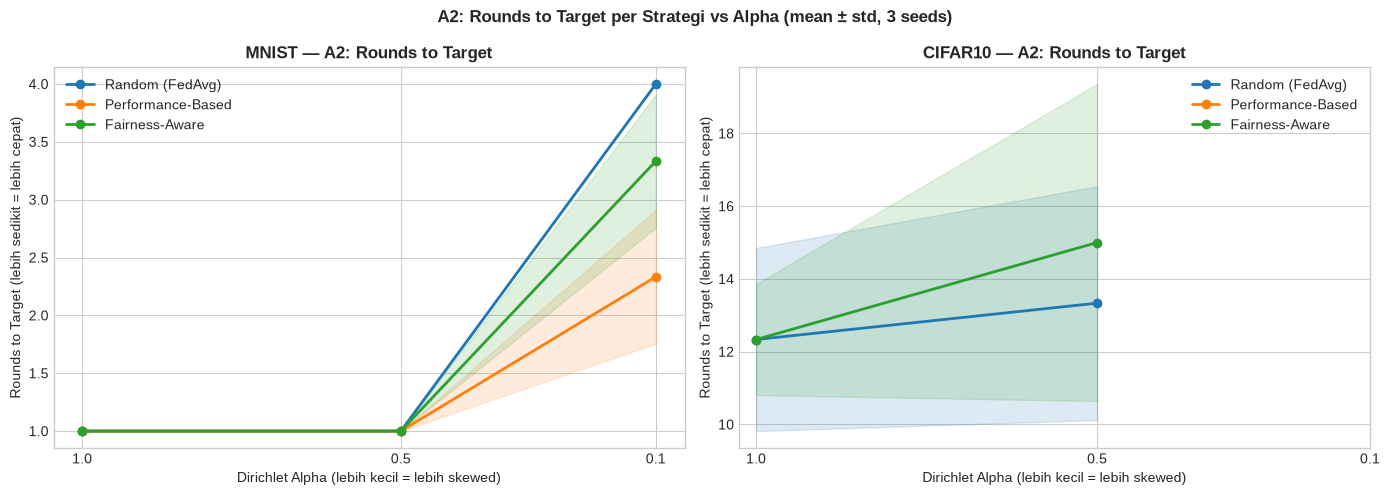

In [90]:
# ── 3C: A2 (Rounds to Target) — line plot per strategi × alpha ──────────

available_datasets = [d for d in DATASETS if d in df.dataset.values]

if available_datasets:
    fig, axes = plt.subplots(1, len(available_datasets),
                             figsize=(7 * len(available_datasets), 5), sharey=False)
    if len(available_datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, available_datasets):
        sub = df[df.dataset == dataset]
        if sub.empty:
            ax.set_visible(False)
            continue

        agg = sub.groupby(['strategy','alpha'])['A2'].agg(['mean','std']).reset_index()

        for strategy in STRATEGIES:
            g = agg[agg.strategy == strategy].sort_values('alpha')
            if g.empty:
                continue
            ax.plot(g['alpha'], g['mean'], marker='o',
                    color=STRATEGY_COLORS[strategy],
                    label=STRATEGY_LABELS[strategy], linewidth=2)
            ax.fill_between(g['alpha'],
                            g['mean'] - g['std'],
                            g['mean'] + g['std'],
                            alpha=0.15, color=STRATEGY_COLORS[strategy])

        ax.set_title(f'{dataset.upper()} — A2: Rounds to Target', fontweight='bold')
        ax.set_xlabel('Dirichlet Alpha (lebih kecil = lebih skewed)')
        ax.set_ylabel('Rounds to Target (lebih sedikit = lebih cepat)')
        ax.set_xticks(ALPHAS)
        ax.legend()
        ax.invert_xaxis()  # kiri=skewed, kanan=uniform (lebih intuitif)

    plt.suptitle('A2: Rounds to Target per Strategi vs Alpha (mean ± std, 3 seeds)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('05_A2_rounds_to_target')

  ✓ Saved: 06_accuracy_progression.png


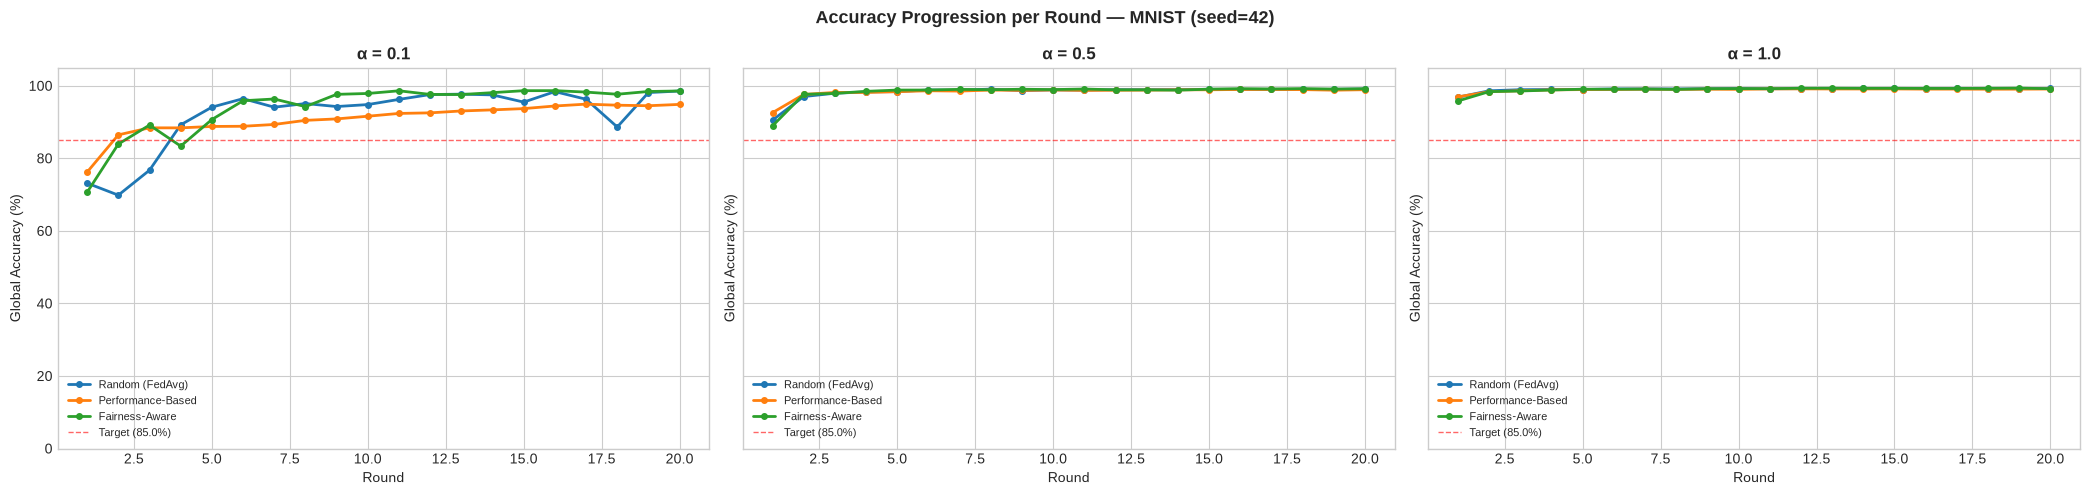

In [91]:
# ── 3D: Accuracy progression per round (per strategi, tiap alpha) ────────

target_dataset = 'mnist'   # ganti ke 'cifar10' kalau sudah ada
seed_show = 42

available_alphas = sorted(df[(df.dataset==target_dataset)&(df.seed==seed_show)]['alpha'].unique())

if available_alphas:
    fig, axes = plt.subplots(1, len(available_alphas),
                             figsize=(7 * len(available_alphas), 5), sharey=True)
    if len(available_alphas) == 1:
        axes = [axes]

    target_line = {'mnist': 85.0, 'cifar10': 70.0}[target_dataset]

    for ax, alpha in zip(axes, available_alphas):
        for strategy in STRATEGIES:
            row = df[(df.dataset==target_dataset)&(df.strategy==strategy)&
                     (df.alpha==alpha)&(df.seed==seed_show)]
            if row.empty or not row.iloc[0]['acc_history']:
                continue
            history = row.iloc[0]['acc_history']
            rounds  = list(range(1, len(history)+1))
            ax.plot(rounds, history,
                    color=STRATEGY_COLORS[strategy],
                    label=STRATEGY_LABELS[strategy],
                    linewidth=2, marker='o', markersize=4)

        ax.axhline(target_line, color='red', linestyle='--', linewidth=1, alpha=0.6,
                   label=f'Target ({target_line}%)')
        ax.set_title(f'α = {alpha}', fontweight='bold', fontsize=12)
        ax.set_xlabel('Round')
        ax.set_ylabel('Global Accuracy (%)')
        ax.set_ylim([0, 105])
        ax.legend(fontsize=8)

    plt.suptitle(f'Accuracy Progression per Round — {target_dataset.upper()} (seed={seed_show})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig('06_accuracy_progression')

## 4. Analisis Fairness (B1, B2, B3)

  ✓ Saved: 07_B1_B2_vs_alpha.png


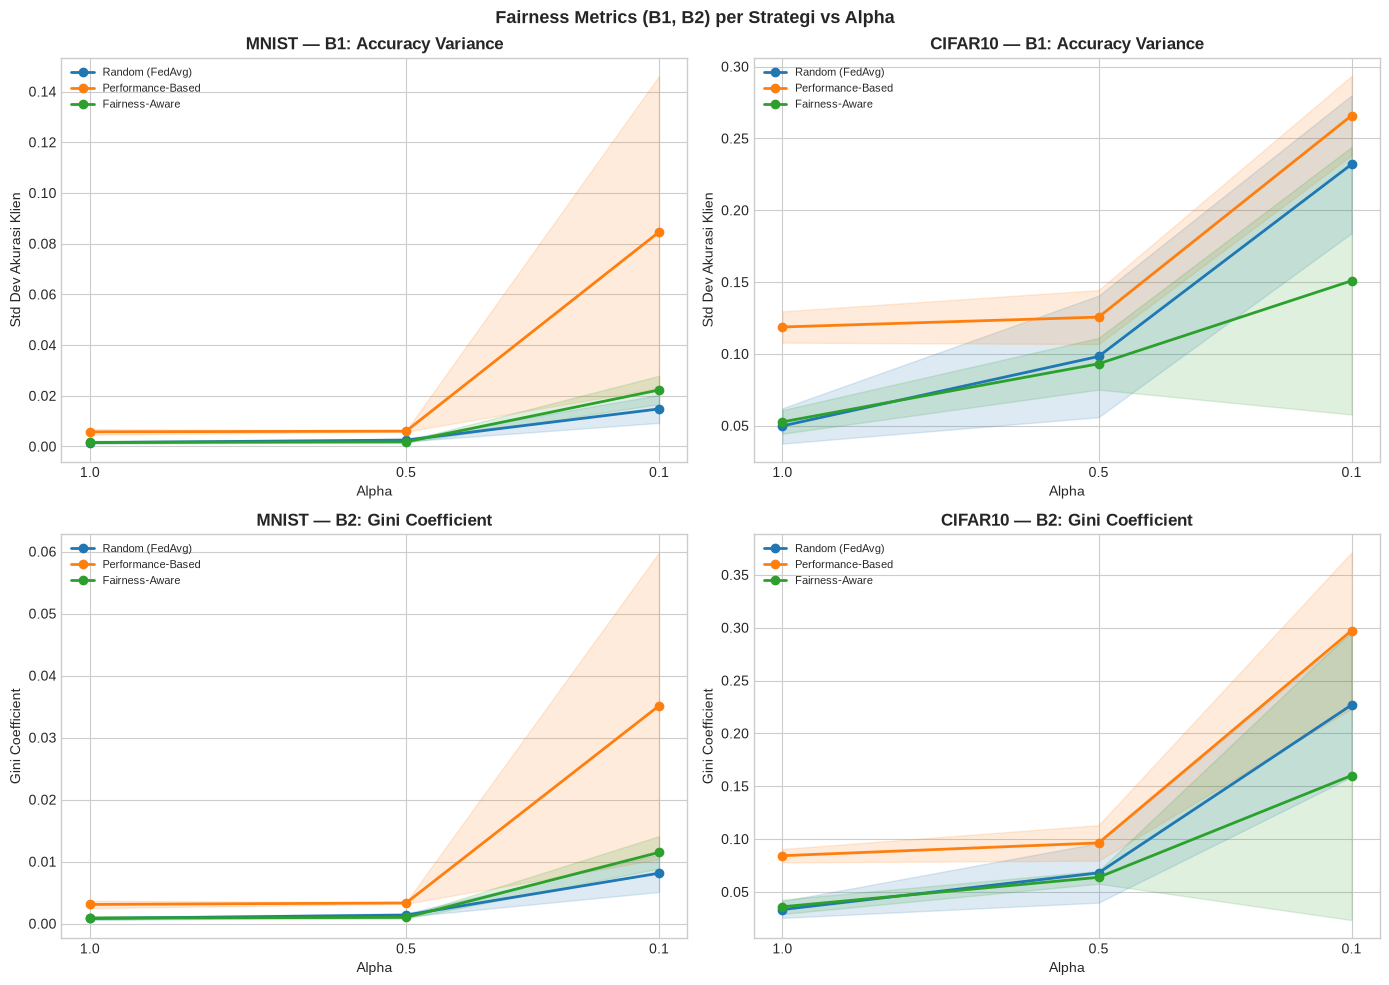

In [92]:
# ── 4A: B1 & B2 line plot vs alpha ───────────────────────────────────────

available_datasets = [d for d in DATASETS if d in df.dataset.values]

if available_datasets:
    fig, axes = plt.subplots(2, len(available_datasets),
                             figsize=(7 * len(available_datasets), 10))
    if len(available_datasets) == 1:
        axes = axes.reshape(-1, 1)

    for col, dataset in enumerate(available_datasets):
        sub = df[df.dataset == dataset]
        if sub.empty:
            continue

        for row, (metric, ylabel, title) in enumerate([
            ('B1', 'Std Dev Akurasi Klien', 'B1: Accuracy Variance'),
            ('B2', 'Gini Coefficient', 'B2: Gini Coefficient'),
        ]):
            ax = axes[row][col]
            agg = sub.groupby(['strategy','alpha'])[metric].agg(['mean','std']).reset_index()

            for strategy in STRATEGIES:
                g = agg[agg.strategy == strategy].sort_values('alpha')
                if g.empty:
                    continue
                ax.plot(g['alpha'], g['mean'], marker='o',
                        color=STRATEGY_COLORS[strategy],
                        label=STRATEGY_LABELS[strategy], linewidth=2)
                ax.fill_between(g['alpha'],
                                (g['mean']-g['std']).clip(lower=0),
                                g['mean']+g['std'],
                                alpha=0.15, color=STRATEGY_COLORS[strategy])

            ax.set_title(f'{dataset.upper()} — {title}', fontweight='bold')
            ax.set_xlabel('Alpha')
            ax.set_ylabel(ylabel)
            ax.set_xticks(ALPHAS)
            ax.invert_xaxis()
            ax.legend(fontsize=8)

    plt.suptitle('Fairness Metrics (B1, B2) per Strategi vs Alpha', fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig('07_B1_B2_vs_alpha')

  ✓ Saved: 08_B3_participation_fairness.png


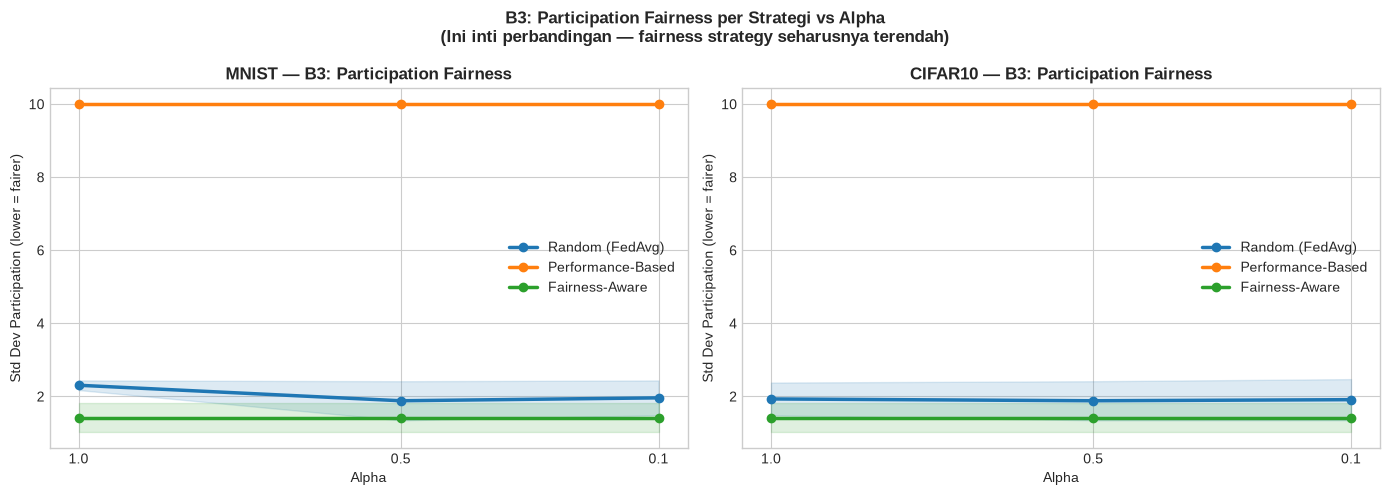

In [93]:
# ── 4B: B3 (Participation Fairness) — yang paling membedakan strategi ───

available_datasets = [d for d in DATASETS if d in df.dataset.values]

if available_datasets:
    fig, axes = plt.subplots(1, len(available_datasets),
                             figsize=(7 * len(available_datasets), 5))
    if len(available_datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, available_datasets):
        sub = df[df.dataset == dataset]
        if sub.empty:
            ax.set_visible(False)
            continue

        agg = sub.groupby(['strategy','alpha'])['B3'].agg(['mean','std']).reset_index()

        for strategy in STRATEGIES:
            g = agg[agg.strategy == strategy].sort_values('alpha')
            if g.empty:
                continue
            ax.plot(g['alpha'], g['mean'], marker='o',
                    color=STRATEGY_COLORS[strategy],
                    label=STRATEGY_LABELS[strategy], linewidth=2.5)
            ax.fill_between(g['alpha'],
                            (g['mean']-g['std']).clip(lower=0),
                            g['mean']+g['std'],
                            alpha=0.15, color=STRATEGY_COLORS[strategy])

        ax.set_title(f'{dataset.upper()} — B3: Participation Fairness', fontweight='bold')
        ax.set_xlabel('Alpha')
        ax.set_ylabel('Std Dev Participation (lower = fairer)')
        ax.set_xticks(ALPHAS)
        ax.invert_xaxis()
        ax.legend()

    plt.suptitle('B3: Participation Fairness per Strategi vs Alpha\n'
                 '(Ini inti perbandingan — fairness strategy seharusnya terendah)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('08_B3_participation_fairness')

  ✓ Saved: 09_participation_pattern.png


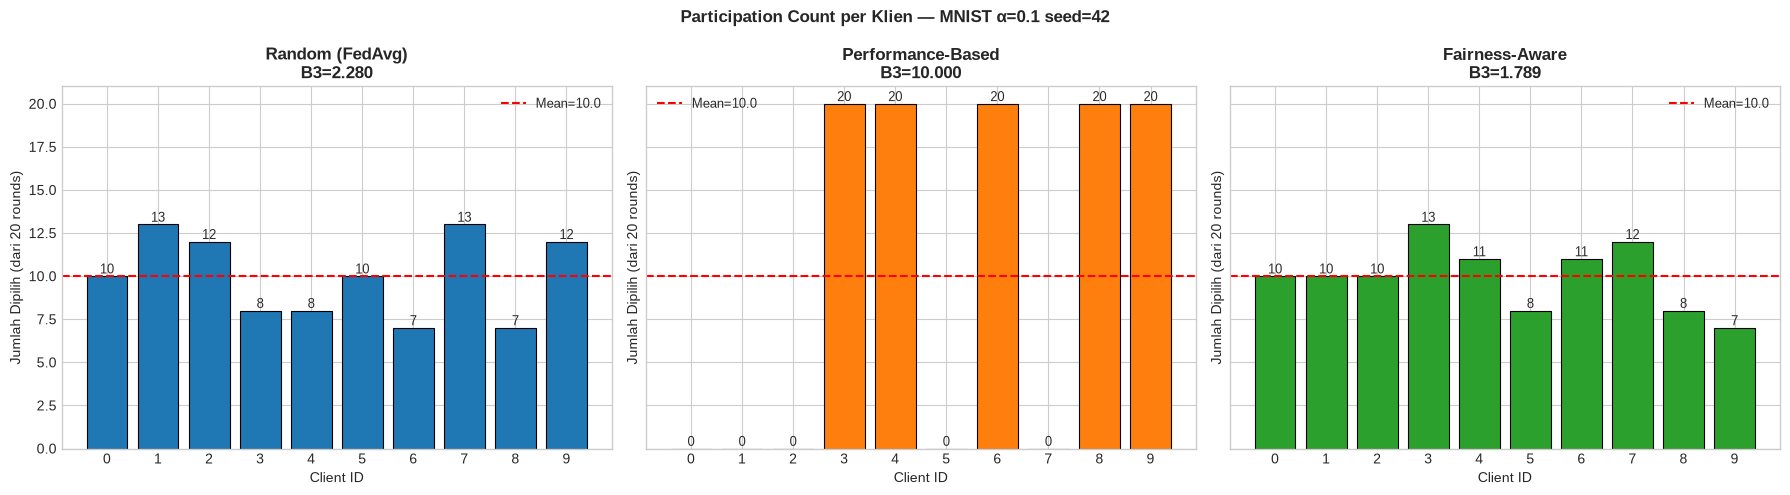

In [94]:
# ── 4C: Participation pattern per klien (bar chart per strategi) ─────────
# Untuk satu kombinasi (alpha=0.1, seed=42) sebagai ilustrasi

target_dataset = 'mnist'
target_alpha   = min(df.alpha.unique()) if not df.empty else 0.1
target_seed    = 42

sub = df[(df.dataset==target_dataset)&(df.alpha==target_alpha)&(df.seed==target_seed)]

available_strategies = [s for s in STRATEGIES if s in sub.strategy.values]

if available_strategies:
    fig, axes = plt.subplots(1, len(available_strategies),
                             figsize=(6 * len(available_strategies), 5), sharey=True)
    if len(available_strategies) == 1:
        axes = [axes]

    for ax, strategy in zip(axes, available_strategies):
        row = sub[sub.strategy == strategy]
        if row.empty:
            ax.set_visible(False)
            continue

        part_data = row.iloc[0]['participation']
        final_counts = part_data.get('final_counts', {})

        if not final_counts:
            ax.set_visible(False)
            continue

        client_ids = sorted(int(k) for k in final_counts.keys())
        counts     = [final_counts[str(c)] for c in client_ids]
        mean_cnt   = np.mean(counts)

        bars = ax.bar(client_ids, counts, color=STRATEGY_COLORS[strategy],
                      edgecolor='black', linewidth=0.8)
        ax.axhline(mean_cnt, color='red', linestyle='--', linewidth=1.5,
                   label=f'Mean={mean_cnt:.1f}')

        for bar, cnt in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    str(int(cnt)), ha='center', va='bottom', fontsize=9)

        b3_val = row.iloc[0]['B3']
        ax.set_title(f'{STRATEGY_LABELS[strategy]}\nB3={b3_val:.3f}',
                     fontweight='bold')
        ax.set_xlabel('Client ID')
        ax.set_ylabel('Jumlah Dipilih (dari 20 rounds)')
        ax.set_xticks(range(10))
        ax.legend(fontsize=9)

    plt.suptitle(f'Participation Count per Klien — {target_dataset.upper()} α={target_alpha} seed={target_seed}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('09_participation_pattern')

## 5. Trade-off Accuracy ↔ Fairness (Pareto)

  ✓ Saved: 10_scatter_A1_vs_B1.png


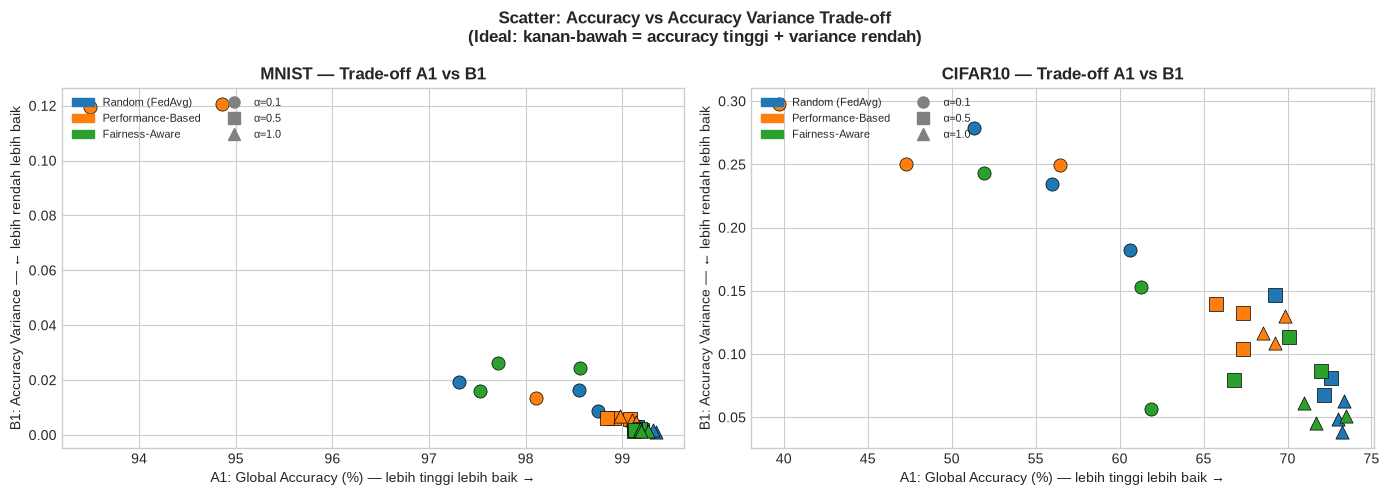

In [95]:
# ── 5A: Scatter A1 vs B1 ─────────────────────────────────────────────────
# Setiap titik = 1 eksperimen (strategy, alpha, dataset, seed)
# Ideal: kanan-bawah = accuracy tinggi + variance rendah

if not df.empty:
    available_datasets = [d for d in DATASETS if d in df.dataset.values]

    fig, axes = plt.subplots(1, len(available_datasets),
                             figsize=(7 * len(available_datasets), 5))
    if len(available_datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, available_datasets):
        sub = df[df.dataset == dataset]
        if sub.empty:
            ax.set_visible(False)
            continue

        for strategy in STRATEGIES:
            g = sub[sub.strategy == strategy]
            for _, r in g.iterrows():
                marker = ALPHA_MARKERS.get(r['alpha'], 'o')
                ax.scatter(r['A1'], r['B1'],
                           color=STRATEGY_COLORS[strategy],
                           marker=marker, s=90, edgecolors='black', linewidths=0.5,
                           zorder=3)

        # Legend strategi
        patches = [mpatches.Patch(color=STRATEGY_COLORS[s], label=STRATEGY_LABELS[s])
                   for s in STRATEGIES]
        # Legend alpha (marker shape)
        alpha_markers = [plt.Line2D([0],[0], marker=m, color='gray',
                                    linestyle='None', markersize=8,
                                    label=f'α={a}')
                         for a, m in ALPHA_MARKERS.items()]
        ax.legend(handles=patches + alpha_markers, fontsize=8,
                  loc='upper left', ncol=2)

        ax.set_xlabel('A1: Global Accuracy (%) — lebih tinggi lebih baik →')
        ax.set_ylabel('B1: Accuracy Variance — ← lebih rendah lebih baik')
        ax.set_title(f'{dataset.upper()} — Trade-off A1 vs B1', fontweight='bold')

    plt.suptitle('Scatter: Accuracy vs Accuracy Variance Trade-off\n'
                 '(Ideal: kanan-bawah = accuracy tinggi + variance rendah)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('10_scatter_A1_vs_B1')

  ✓ Saved: 11_scatter_A1_vs_B3.png


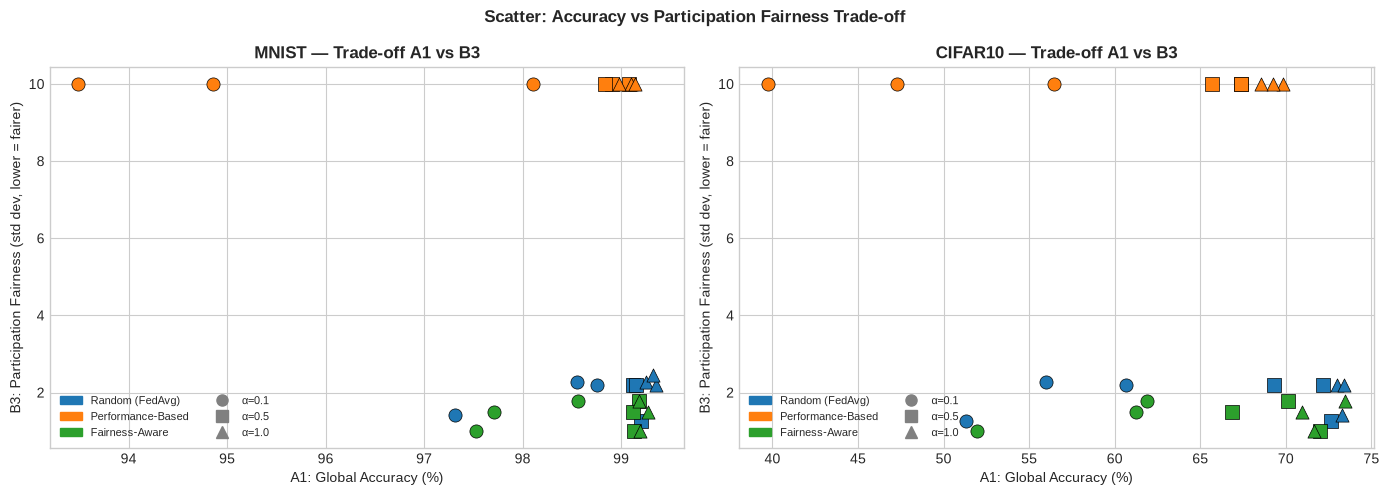

In [96]:
# ── 5B: Scatter A1 vs B3 (accuracy vs participation fairness) ────────────

if not df.empty:
    available_datasets = [d for d in DATASETS if d in df.dataset.values]

    fig, axes = plt.subplots(1, len(available_datasets),
                             figsize=(7 * len(available_datasets), 5))
    if len(available_datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, available_datasets):
        sub = df[df.dataset == dataset]
        if sub.empty:
            ax.set_visible(False)
            continue

        for strategy in STRATEGIES:
            g = sub[sub.strategy == strategy]
            for _, r in g.iterrows():
                marker = ALPHA_MARKERS.get(r['alpha'], 'o')
                ax.scatter(r['A1'], r['B3'],
                           color=STRATEGY_COLORS[strategy],
                           marker=marker, s=90, edgecolors='black', linewidths=0.5,
                           zorder=3)

        patches = [mpatches.Patch(color=STRATEGY_COLORS[s], label=STRATEGY_LABELS[s])
                   for s in STRATEGIES]
        alpha_markers = [plt.Line2D([0],[0], marker=m, color='gray',
                                    linestyle='None', markersize=8, label=f'α={a}')
                         for a, m in ALPHA_MARKERS.items()]
        ax.legend(handles=patches + alpha_markers, fontsize=8, ncol=2)

        ax.set_xlabel('A1: Global Accuracy (%)')
        ax.set_ylabel('B3: Participation Fairness (std dev, lower = fairer)')
        ax.set_title(f'{dataset.upper()} — Trade-off A1 vs B3', fontweight='bold')

    plt.suptitle('Scatter: Accuracy vs Participation Fairness Trade-off',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('11_scatter_A1_vs_B3')

## 6. Konsistensi Cross-Dataset (MNIST vs CIFAR-10)

  ✓ Saved: 12_cross_dataset_ranking.png


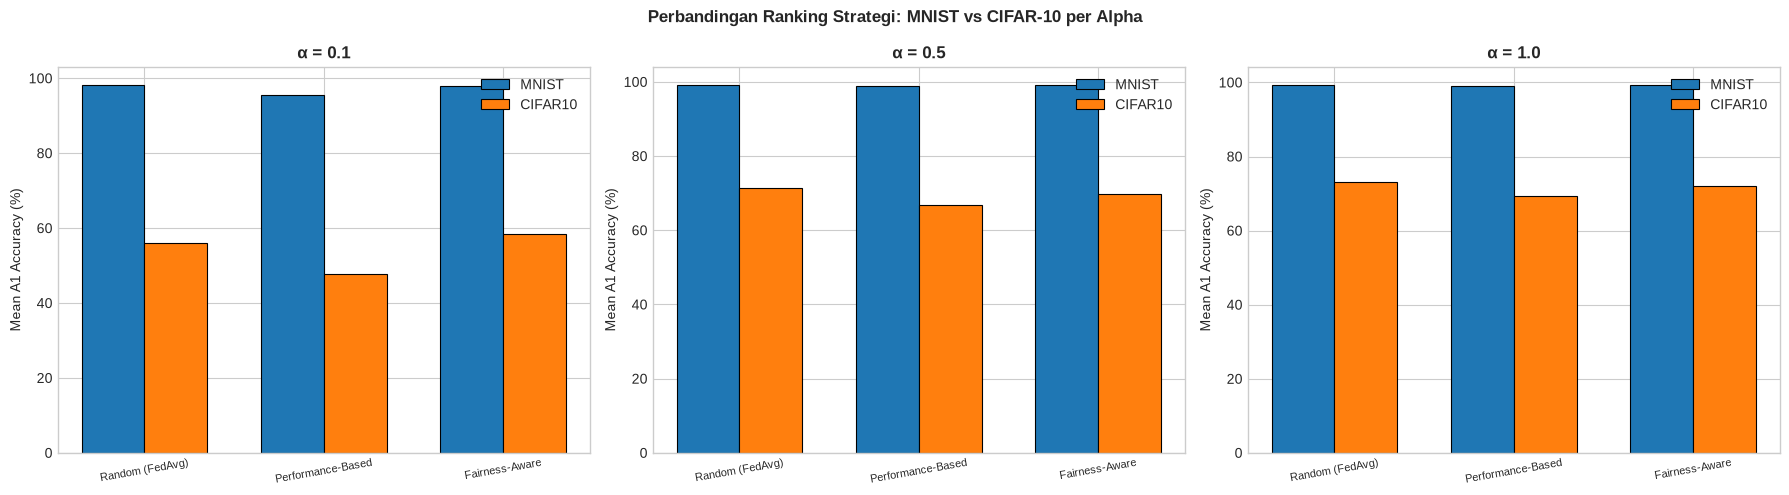

In [97]:
# ── 6: Side-by-side ranking per alpha ──────────────────────────────────
# Apakah ranking strategi berubah antara MNIST dan CIFAR-10?

both_available = all(d in df.dataset.values for d in DATASETS)

if not both_available:
    print('Butuh hasil dari kedua dataset (MNIST + CIFAR-10) untuk cell ini.')
    print(f'  Tersedia: {list(df.dataset.unique())}')
else:
    available_alphas = sorted(df.alpha.unique())
    fig, axes = plt.subplots(1, len(available_alphas),
                             figsize=(6 * len(available_alphas), 5))
    if len(available_alphas) == 1:
        axes = [axes]

    for ax, alpha in zip(axes, available_alphas):
        sub = df[df.alpha == alpha]
        agg = sub.groupby(['dataset','strategy'])['A1'].mean().reset_index()

        x = np.arange(len(STRATEGIES))
        width = 0.35

        for i, dataset in enumerate(DATASETS):
            vals = []
            for s in STRATEGIES:
                v = agg[(agg.dataset==dataset)&(agg.strategy==s)]['A1']
                vals.append(v.values[0] if len(v) > 0 else 0)
            offset = (i - 0.5) * width
            bars = ax.bar(x + offset, vals, width, label=dataset.upper(),
                          edgecolor='black', linewidth=0.8)

        ax.set_xticks(x)
        ax.set_xticklabels([STRATEGY_LABELS[s] for s in STRATEGIES], fontsize=8)
        ax.set_title(f'α = {alpha}', fontweight='bold')
        ax.set_ylabel('Mean A1 Accuracy (%)')
        ax.legend()
        ax.tick_params(axis='x', rotation=10)

    plt.suptitle('Perbandingan Ranking Strategi: MNIST vs CIFAR-10 per Alpha',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('12_cross_dataset_ranking')

## 7. Summary Table & Comprehensive Metrics

In [98]:
# ── 7A: Tabel ringkasan mean ± std semua metrik ──────────────────────────

if not df.empty:
    summary_rows = []
    for dataset in DATASETS:
        for strategy in STRATEGIES:
            for alpha in ALPHAS:
                sub = df[(df.dataset==dataset)&(df.strategy==strategy)&(df.alpha==alpha)]
                if sub.empty:
                    continue
                summary_rows.append({
                    'Dataset':  dataset.upper(),
                    'Strategy': STRATEGY_LABELS[strategy],
                    'Alpha':    alpha,
                    'A1 (mean±std)': f"{sub['A1'].mean():.2f}±{sub['A1'].std():.2f}",
                    'A2 (mean)':     f"{sub['A2'].mean():.1f}",
                    'B1 (mean±std)': f"{sub['B1'].mean():.4f}±{sub['B1'].std():.4f}",
                    'B2 (mean±std)': f"{sub['B2'].mean():.4f}±{sub['B2'].std():.4f}",
                    'B3 (mean±std)': f"{sub['B3'].mean():.3f}±{sub['B3'].std():.3f}",
                })

    df_summary = pd.DataFrame(summary_rows)

    for dataset in df_summary['Dataset'].unique():
        print(f'\n=== {dataset} ===')
        sub = df_summary[df_summary['Dataset'] == dataset].drop(columns='Dataset')
        print(sub.to_string(index=False))

    df_summary.to_csv(ROOT / 'notebooks' / 'summary_all_experiments.csv', index=False)
    print('\n✓ Saved: notebooks/summary_all_experiments.csv')


=== MNIST ===
         Strategy  Alpha A1 (mean±std) A2 (mean) B1 (mean±std) B2 (mean±std) B3 (mean±std)
  Random (FedAvg)    0.1    98.20±0.78       4.0 0.0148±0.0055 0.0081±0.0030   1.962±0.476
  Random (FedAvg)    0.5    99.16±0.04       1.0 0.0025±0.0005 0.0014±0.0003   1.882±0.535
  Random (FedAvg)    1.0    99.31±0.05       1.0 0.0015±0.0004 0.0008±0.0003   2.307±0.131
Performance-Based    0.1    95.49±2.37       2.3 0.0846±0.0615 0.0351±0.0247  10.000±0.000
Performance-Based    0.5    98.94±0.12       1.0 0.0060±0.0002 0.0033±0.0001  10.000±0.000
Performance-Based    1.0    99.07±0.08       1.0 0.0058±0.0011 0.0031±0.0006  10.000±0.000
   Fairness-Aware    0.1    97.93±0.55       3.3 0.0223±0.0056 0.0115±0.0026   1.424±0.398
   Fairness-Aware    0.5    99.14±0.03       1.0 0.0018±0.0004 0.0010±0.0002   1.424±0.398
   Fairness-Aware    1.0    99.21±0.05       1.0 0.0016±0.0004 0.0009±0.0002   1.424±0.398

=== CIFAR10 ===
         Strategy  Alpha A1 (mean±std) A2 (mean) B1 (mean±

## 8. Statistical Significance (ANOVA)

In [99]:
def run_two_way_anova_fixed(results_df, dependent_var):
    """Fixed version dengan p_unc (underscore) bukan p-unc (hyphen)"""
    import pingouin as pg
    
    required_cols = {"strategy", "alpha", dependent_var}
    missing = required_cols - set(results_df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")
    
    aov = pg.anova(
        data=results_df,
        dv=dependent_var,
        between=["strategy", "alpha"],
        detailed=True,
    )
    
    def _extract(source):
        row = aov[aov["Source"] == source]
        if row.empty:
            return float("nan"), float("nan")
        return float(row["F"].values[0]), float(row["p_unc"].values[0])  # ← p_unc (underscore)

    F_strat, p_strat = _extract("strategy")
    F_alpha, p_alpha = _extract("alpha")
    F_inter, p_inter = _extract("strategy * alpha")

    return {
        "F_strategy": round(float(F_strat), 4),
        "p_strategy": round(float(p_strat), 4),
        "F_alpha": round(float(F_alpha), 4),
        "p_alpha": round(float(p_alpha), 4),
        "F_interaction": round(float(F_inter), 4),
        "p_interaction": round(float(p_inter), 4),
        "significant_strategy": float(p_strat) < 0.05,
        "significant_alpha": float(p_alpha) < 0.05,
        "significant_interaction": float(p_inter) < 0.05,
        "dependent_var": dependent_var,
    }

In [100]:
# ── 8: Two-way ANOVA: Strategy × Alpha → setiap metrik ──────────────────
# Butuh minimal 2 strategi dan 2 alpha tersedia

from src.metrics.evaluator import run_two_way_anova

n_strategies = df['strategy'].nunique()
n_alphas     = df['alpha'].nunique()

if n_strategies < 2 or n_alphas < 2:
    print(f'ANOVA butuh minimal 2 strategi & 2 alpha.')
    print(f'  Tersedia: {n_strategies} strategi, {n_alphas} alpha')
    print('  Jalankan lebih banyak eksperimen dulu.')
else:
    anova_rows = []

    for dataset in df['dataset'].unique():
        sub = df[df.dataset == dataset].copy()
        sub['alpha_str'] = sub['alpha'].astype(str)

        for metric, col in [('A1','A1'), ('B1','B1'), ('B2','B2'), ('B3','B3')]:
            try:
                anova_df = sub[['strategy','alpha_str', col]].rename(
                    columns={'alpha_str': 'alpha', col: metric})
                result = run_two_way_anova_fixed(anova_df, metric)
                anova_rows.append({
                    'Dataset':  dataset.upper(),
                    'Metric':   metric,
                    'F_strategy': result['F_strategy'],
                    'p_strategy': result['p_strategy'],
                    'Sig_strategy': '✓' if result['significant_strategy'] else '✗',
                    'F_alpha':    result['F_alpha'],
                    'p_alpha':    result['p_alpha'],
                    'Sig_alpha':  '✓' if result['significant_alpha'] else '✗',
                    'F_interaction': result['F_interaction'],
                    'p_interaction': result['p_interaction'],
                    'Sig_interaction': '✓' if result['significant_interaction'] else '✗',
                })
            except Exception as e:
                print(f'  ANOVA gagal untuk {dataset}/{metric}: {e}')

    if anova_rows:
        df_anova = pd.DataFrame(anova_rows)
        for dataset in df_anova['Dataset'].unique():
            print(f'\n=== ANOVA: {dataset} (H0: tidak ada perbedaan signifikan) ===')
            sub = df_anova[df_anova['Dataset']==dataset].drop(columns='Dataset')
            print(sub.to_string(index=False))
        print('\n✓: signifikan (p < 0.05) | ✗: tidak signifikan')


=== ANOVA: MNIST (H0: tidak ada perbedaan signifikan) ===
Metric  F_strategy  p_strategy Sig_strategy  F_alpha  p_alpha Sig_alpha  F_interaction  p_interaction Sig_interaction
    A1      4.0889      0.0344            ✓  15.3722   0.0001         ✓         2.6145         0.0698               ✗
    B1      4.3048      0.0297            ✓   9.7823   0.0013         ✓         3.0314         0.0449               ✓
    B2      4.2432      0.0309            ✓  11.7065   0.0006         ✓         2.6038         0.0706               ✗
    B3   1842.9271      0.0000            ✓   0.4566   0.6406         ✗         0.4566         0.7665               ✗

=== ANOVA: CIFAR10 (H0: tidak ada perbedaan signifikan) ===
Metric  F_strategy  p_strategy Sig_strategy  F_alpha  p_alpha Sig_alpha  F_interaction  p_interaction Sig_interaction
    A1      5.9576      0.0103            ✓  53.5534   0.0000         ✓         0.9885         0.4388               ✗
    B1      7.1733      0.0051            ✓  31.1745  

## 9. Early Insights (Tersedia Sekarang)

In [101]:
# ── 9: Print insight otomatis dari data yang ada ─────────────────────────

if df.empty:
    print('Belum ada data.')
else:
    print('='*60)
    print('EARLY INSIGHTS')
    print('='*60)

    for dataset in df['dataset'].unique():
        sub = df[df.dataset == dataset]
        agg = sub.groupby('strategy')[['A1','A2','B1','B2','B3']].mean()

        best_acc   = agg['A1'].idxmax()
        fastest    = agg['A2'].idxmin() if agg['A2'].notna().any() else 'N/A'
        fairest_b1 = agg['B1'].idxmin()
        fairest_b3 = agg['B3'].idxmin()

        print(f'\n{dataset.upper()}:')
        print(f'  Accuracy tertinggi    : {STRATEGY_LABELS.get(best_acc, best_acc)} (A1={agg["A1"][best_acc]:.2f}%)')
        print(f'  Konvergensi tercepat  : {STRATEGY_LABELS.get(fastest, fastest)}')
        print(f'  Fairness terbaik (B1) : {STRATEGY_LABELS.get(fairest_b1, fairest_b1)} (B1={agg["B1"][fairest_b1]:.6f})')
        print(f'  Fairness terbaik (B3) : {STRATEGY_LABELS.get(fairest_b3, fairest_b3)} (B3={agg["B3"][fairest_b3]:.4f})')

EARLY INSIGHTS

MNIST:
  Accuracy tertinggi    : Random (FedAvg) (A1=98.89%)
  Konvergensi tercepat  : Performance-Based
  Fairness terbaik (B1) : Random (FedAvg) (B1=0.006291)
  Fairness terbaik (B3) : Fairness-Aware (B3=1.4240)

CIFAR10:
  Accuracy tertinggi    : Random (FedAvg) (A1=66.85%)
  Konvergensi tercepat  : Random (FedAvg)
  Fairness terbaik (B1) : Fairness-Aware (B1=0.098900)
  Fairness terbaik (B3) : Fairness-Aware (B3=1.4240)

Eksperimen tersedia : 54/54

Selanjutnya:
  → Jalankan sisa eksperimen MNIST (0 lagi)
